In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [23]:
#LOAD DATA
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/dl06/cleaned_data_2.csv")

df.shape
df.head()

,tieu_de,dia_chi,gia_ban,gia_ban_num,dien_tich,dien_tich_num,price_per_m2,so_phong_ngu_num,so_phong_ve_sinh_num,quan,quan_encoded,text_clean
0,🍀VÂN KIỀU AN CƯ🍀 40m2 - Hẻm Ô Tô - Gần mặt tiề...,"Đường Lê Quang Định, Phường 7, Quận Bình Thạnh...","3,85 tỷ",3.850000e+09,36 m²,36.0,1.069444e+08,2.0,2.0,binh_thanh,0,vân kiều an_cư 40m2 hẻm ô_tô mặt_tiền ngang to...
1,"9.xty,Nhà Hẻm Xe Hơi,Xây Mới Khu VIP giáp Phạm...","Đường Phạm Văn Đồng, Phường 13, Quận Bình Thạn...","9,79 tỷ",9.790000e+09,62 m²,62.0,1.579032e+08,4.0,3.0,binh_thanh,0,9 xty hẻm xe_hơi xây khu vip giáp phạm văn đồn...
2,XE HƠI NGỦ TRONG NHÀ- NGANG 7M - HIẾM - NƠ TRA...,"Đường Nơ Trang Long, Phường 13, Quận Bình Thạn...","7,2 tỷ",7.200000e+09,54 m²,54.0,1.333333e+08,3.0,2.0,binh_thanh,0,xe_hơi ngủ ngang 7m hiếm nơ trang long p13 bt ...
3,🛎️ NHÀ LỚN HẺM ÔTÔ NGAY HÀNG XANH – TIỆN XÂY M...,"Đường Xô Viết Nghệ Tĩnh, Phường 21, Quận Bình ...","8,5 tỷ",8.500000e+09,83 m²,83.0,1.024096e+08,3.0,3.0,binh_thanh,0,hẻm ôtô hàng xanh tiện xây 8 5 tỷ e45 hẻm ôtô ...
4,Nhà hẻm cách đường mặt tiền 20m,"Đường Chu Văn An, Phường 12, Quận Bình Thạnh, ...","2,85 tỷ",2.850000e+09,18 m²,18.0,1.583333e+08,2.0,1.0,binh_thanh,0,hẻm đường mặt_tiền 20m hẻm đường mặt_tiền 20m ...


In [24]:
#TẠO FEATURE
features = [
    "gia_ban_num",
    "dien_tich_num",
    "price_per_m2",
    "quan_encoded"
]

X = df[features]

In [25]:
#SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

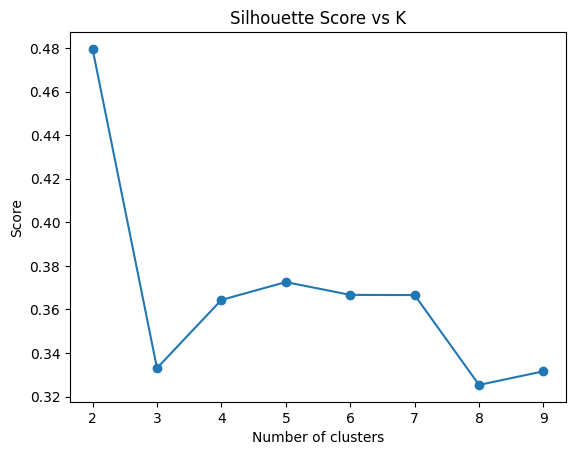

In [26]:
#FIND BEST K (Silhouette)
scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of clusters")
plt.ylabel("Score")
plt.show()


k=2

In [27]:
best_k = 2

#KMEANS

In [28]:
# KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

#GMM

In [29]:
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
df["cluster_gmm"] = gmm.fit_predict(X_scaled)

#AGGLOMERATIVE

In [30]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df["cluster_agg"] = agg.fit_predict(X_scaled)

#VISUALIZE

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.45157953 0.30935805]


/tmp/ipykernel_822/1285453949.py:5: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(x="pca1", y="pca2", hue="cluster_kmeans",
/tmp/ipykernel_822/1285453949.py:9: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(x="pca1", y="pca2", hue="cluster_gmm",
/tmp/ipykernel_822/1285453949.py:13: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.scatterplot(x="pca1", y="pca2", hue="cluster_agg",


Text(0.5, 1.0, 'Agglomerative')

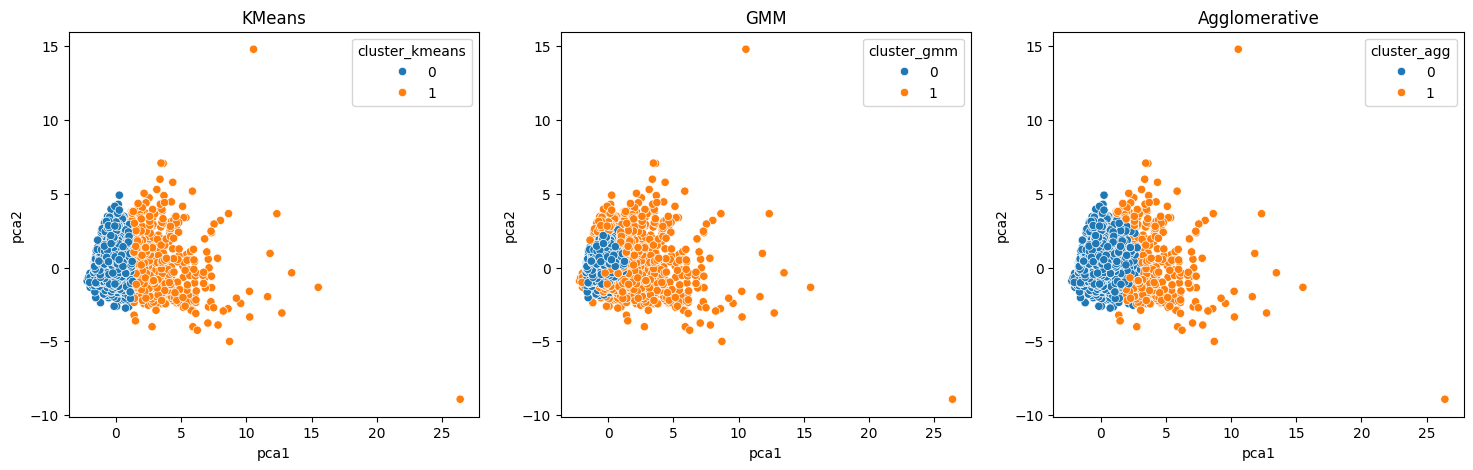

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = sns.color_palette("tab10", 8)  # 8 màu rất khác nhau

sns.scatterplot(x="pca1", y="pca2", hue="cluster_kmeans",
                data=df, ax=axes[0], palette=palette)
axes[0].set_title("KMeans")

sns.scatterplot(x="pca1", y="pca2", hue="cluster_gmm",
                data=df, ax=axes[1], palette=palette)
axes[1].set_title("GMM")

sns.scatterplot(x="pca1", y="pca2", hue="cluster_agg",
                data=df, ax=axes[2], palette=palette)
axes[2].set_title("Agglomerative")

In [33]:
#EVALUATE
kmeans_score = silhouette_score(X_scaled, df["cluster_kmeans"])
gmm_score = silhouette_score(X_scaled, df["cluster_gmm"])
agg_score = silhouette_score(X_scaled, df["cluster_agg"])

print("KMeans Score:", kmeans_score)
print("GMM Score:", gmm_score)
print("Agglomerative Score:", agg_score)

KMeans Score: 0.47962366844585114
GMM Score: 0.36913971025644987
Agglomerative Score: 0.5932715232258085


In [34]:
#Xem trung bình từng cụm
cluster_analysis = df.groupby("cluster_kmeans")[features].mean()
print(cluster_analysis)

                 gia_ban_num  dien_tich_num  price_per_m2  quan_encoded
cluster_kmeans                                                         
0               6.486887e+09      47.931471  1.446977e+08      0.832855
1               1.992091e+10     114.424665  1.959344e+08      0.787047


In [35]:
cluster_analysis_norm = (cluster_analysis - cluster_analysis.mean()) / cluster_analysis.std()
print(cluster_analysis_norm)

                gia_ban_num  dien_tich_num  price_per_m2  quan_encoded
cluster_kmeans                                                        
0                 -0.707107      -0.707107     -0.707107      0.707107
1                  0.707107       0.707107      0.707107     -0.707107


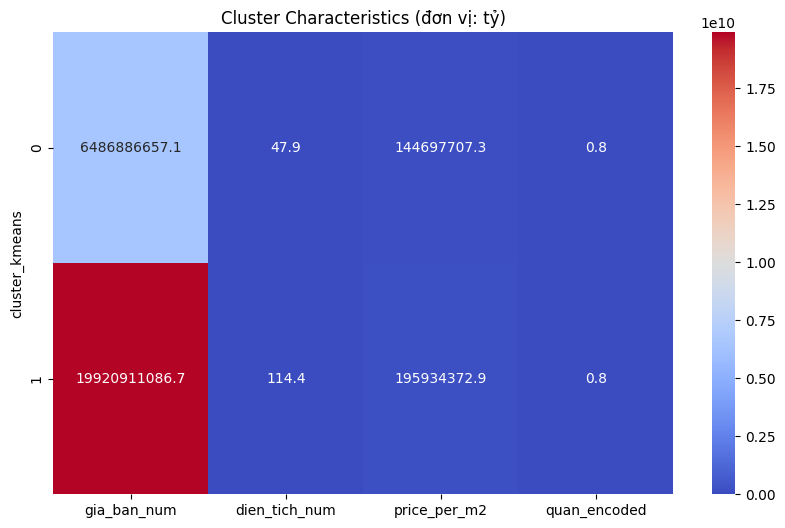

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(cluster_analysis, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Cluster Characteristics (đơn vị: tỷ)")
plt.show()

In [37]:
print(df["cluster_kmeans"].value_counts().sort_index())

cluster_kmeans
0    6970
1     911
Name: count, dtype: int64
